### Notebook used to visualize the generated datasets

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, Dropdown, Layout, Checkbox, VBox, HBox

%matplotlib widget

In [2]:
facies_properties = {
    'undefined':           {'val': 0,  'color': "#ff0000", 'grain_size': 0,  'porosity_class': 0,    'description': "Background/Undefined"},
    'channel_lag':         {'val': 1,  'color': "#f1970f", 'grain_size': 13, 'porosity_class': -2,   'description': "Active channel fill, coarse-grained"},
    'point_bar':           {'val': 2,  'color': "#f3dd12", 'grain_size': 10, 'porosity_class': 1,    'description': "Lower energy channel margins"},
    'sand_plug':           {'val': 3,  'color': "#af8f00", 'grain_size': 9,  'porosity_class': 2,    'description': "Fine-grained oxbow/plug fill"},
    'crevasse_splay_core': {'val': 4,  'color': "#fffc65", 'grain_size': 9,  'porosity_class': 2,    'description': "Proximal high-energy splay"},
    'crevasse_channel':    {'val': 5,  'color': "#ffd986", 'grain_size': 8,  'porosity_class': 3,    'description': "Feeder channel for splays"},
    'crevasse_splay_delta':{'val': 6,  'color': "#ff9853", 'grain_size': 7,  'porosity_class': 2,    'description': "Distal fan-like splay deposit"},
    'levee':               {'val': 7,  'color': "#27ae60", 'grain_size': 6,  'porosity_class': 5,    'description': "Sand/silt ridges bordering channel"},
    'overbank':            {'val': 8,  'color': "#33ff00", 'grain_size': 3,  'porosity_class': 8,    'description': "Stabilized/vegetated levee"},
    'mud_plug':            {'val': 9,  'color': "#fff7db", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Fine silts/clays far from channel"},
    'hemipelagic_plug':    {'val': 10, 'color': "#7a7d80", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Silts near active channel belts"},
    'wetland':             {'val': 11, 'color': "#d862f0", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Organic rich, very fine sediment"},
    'draping':             {'val': 12, 'color': "#8dd5e7", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lateral accretion sand bodies"},
    'pelagic':             {'val': 13, 'color': "#3498db", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lacustrine clay/silt"}
}

val_to_info = {
    info['val']: {
        'color': info['color'], 
        'name': key.replace('_', ' ').title() # Converts 'channel_lag' to 'Channel Lag'
    } 
    for key, info in facies_properties.items()
}

## 2D plot

In [9]:
def create_interactive_viewer(file_path, is_one_hot=False):
    # Load data once to get dimensions
    data = np.load(file_path)
    fac_data = data['facies']
    if is_one_hot and fac_data.ndim == 4:
        fac_vol = np.argmax(fac_data, axis=0)
    else:
        fac_vol = fac_data[0] if fac_data.ndim == 4 else fac_data
    
    nz, ny, nx = fac_vol.shape
    unique_facies = np.sort(np.unique(fac_vol))
    
    # Pre-calculate colors for the colormap
    current_colors = [val_to_info[v]['color'] if v in val_to_info else "#333333" for v in unique_facies]
    cmap = ListedColormap(current_colors)
    norm = BoundaryNorm(np.append(unique_facies, unique_facies[-1] + 1) - 0.5, len(unique_facies))

    def update_plot(axis, index):
        plt.figure(figsize=(12, 7))
        
        # Slicing
        if axis == 'Z (Map View)':
            slc = fac_vol[index, :, :]
            ylabel, xlabel = "y (North)", "x (East)"
        elif axis == 'Y (XS East-West)':
            slc = fac_vol[:, index, :]
            ylabel, xlabel = "z (Depth)", "x (East)"
        else: # X
            slc = fac_vol[:, :, index]
            ylabel, xlabel = "z (Depth)", "y (North)"

        plt.imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='auto')
        
        # Legend
        vals_in_slice = np.unique(slc)
        legend_elements = [mpatches.Patch(facecolor=val_to_info[v]['color'], label=f"({v}) {val_to_info[v]['name']}") 
                           for v in vals_in_slice if v in val_to_info]
        
        plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Facies")
        plt.title(f"FLUMY Slice: {axis} at Index {index}", fontsize=14)
        plt.ylabel(ylabel)
        plt.xlabel(xlabel)
        plt.show()

    # Create UI Elements
    axis_dropdown = Dropdown(options=['Z (Map View)', 'Y (XS East-West)', 'X (XS North-South)'], value='Z (Map View)', description='Axis:')
    
    # Dynamic slider range based on axis selection
    index_slider = IntSlider(min=0, max=nz-1, step=1, value=nz//2, description='Slice:', layout=Layout(width='50%'))

    def on_axis_change(change):
        if change['new'] == 'Z (Map View)':
            index_slider.max = nz - 1
        elif change['new'] == 'Y (XS East-West)':
            index_slider.max = ny - 1
        else:
            index_slider.max = nx - 1
        index_slider.value = index_slider.max // 2

    axis_dropdown.observe(on_axis_change, names='value')

    interact(update_plot, axis=axis_dropdown, index=index_slider)

# --- Usage ---
# In a Jupyter Notebook cell:
base = "test_outputs"
create_interactive_viewer(os.path.join(base, "sample_101.npz"))

interactive(children=(Dropdown(description='Axis:', options=('Z (Map View)', 'Y (XS East-West)', 'X (XS North-…

## 3D plot

interactive(children=(IntSlider(value=128, description='X', max=255), IntSlider(value=128, description='Y', ma…

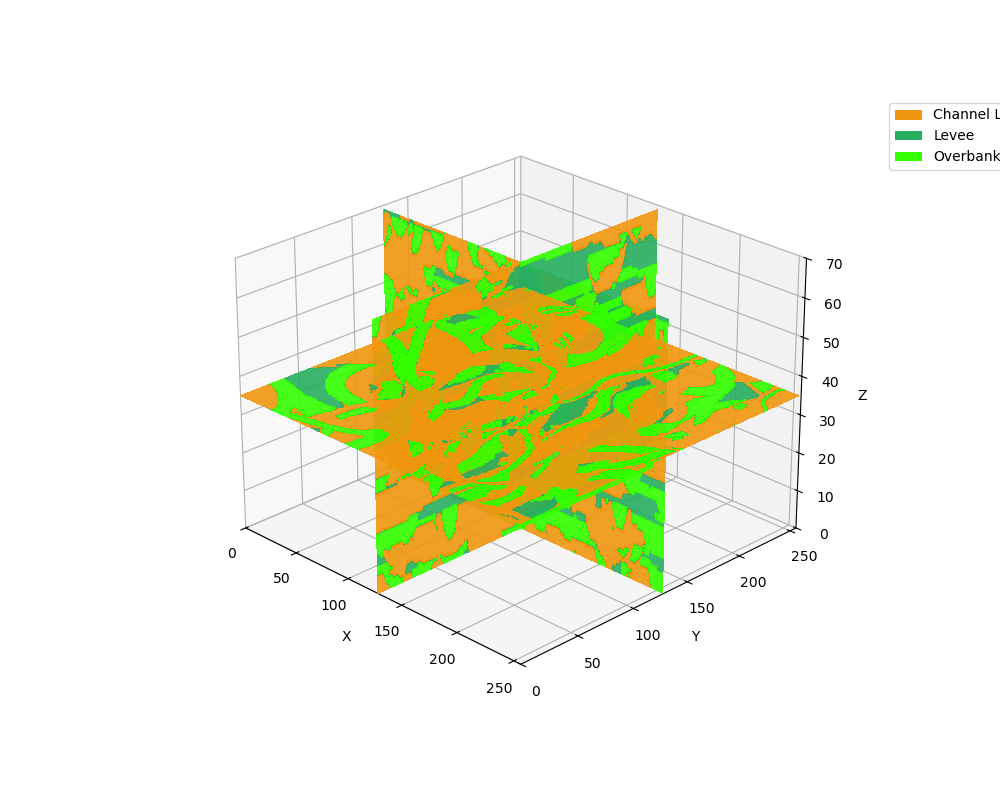

In [4]:
def visualize_3d_smooth(file_path, is_one_hot=False):
    # --- 1. Load and Cache Data ---
    data = np.load(file_path)
    fac_data = data['facies']
    fac_vol = np.argmax(fac_data, axis=0) if (is_one_hot and fac_data.ndim == 4) else (fac_data[0] if fac_data.ndim == 4 else fac_data)
    
    nz, ny, nx = fac_vol.shape
    unique_facies = np.sort(np.unique(fac_vol))
    
    # --- 2. Setup Colormap ---
    current_colors = [val_to_info[v]['color'] if v in val_to_info else "#333333" for v in unique_facies]
    cmap = ListedColormap(current_colors)
    norm = BoundaryNorm(np.append(unique_facies, unique_facies[-1] + 1) - 0.5, len(unique_facies))

    # Pre-generate grids once to save CPU
    x_coords, y_coords, z_coords = np.arange(nx), np.arange(ny), np.arange(nz)
    gz_x, gz_y = np.meshgrid(x_coords, y_coords)
    gy_x, gy_z = np.meshgrid(x_coords, z_coords)
    gx_y, gx_z = np.meshgrid(y_coords, z_coords)

    # Create the persistent figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=25, azim=-45)

    def update_plot(x_idx, y_idx, z_idx, show_x, show_y, show_z):
        ax.clear() # Clear only the axes content, not the whole figure object
        
        # We use 'continuous_update=True' in the sliders for smoothness
        # and re-render only the active planes.
        
        if show_z:
            ax.contourf(gz_x, gz_y, fac_vol[z_idx, :, :], 
                        zdir='z', offset=z_idx, cmap=cmap, norm=norm, alpha=0.9)
        if show_y:
            ax.contourf(gy_x, fac_vol[:, y_idx, :], gy_z, 
                        zdir='y', offset=y_idx, cmap=cmap, norm=norm, alpha=0.9)
        if show_x:
            ax.contourf(fac_vol[:, :, x_idx], gx_y, gx_z, 
                        zdir='x', offset=x_idx, cmap=cmap, norm=norm, alpha=0.9)

        ax.set_xlim(0, nx); ax.set_ylim(0, ny); ax.set_zlim(0, nz)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        
        # Only show legend for what's in the volume to save space
        legend_elements = [mpatches.Patch(facecolor=val_to_info[v]['color'], label=val_to_info[v]['name']) 
                           for v in unique_facies if v in val_to_info]
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.1, 1))
        
        fig.canvas.draw_idle() # Optimized redraw for interactive backends

    # --- 3. Interaction with continuous_update=True ---
    interact(update_plot, 
             x_idx=IntSlider(min=0, max=nx-1, value=nx//2, continuous_update=True, description='X'),
             y_idx=IntSlider(min=0, max=ny-1, value=ny//2, continuous_update=True, description='Y'),
             z_idx=IntSlider(min=0, max=nz-1, value=nz//2, continuous_update=True, description='Z'),
             show_x=Checkbox(value=True, description='Show X'),
             show_y=Checkbox(value=True, description='Show Y'),
             show_z=Checkbox(value=True, description='Show Z'))

visualize_3d_smooth(os.path.join(base, "sample_3.npz"))

## Ananlyse all samples:

In [5]:
linux_base = "test_outputs"
files = [f for f in os.listdir(linux_base) if f.endswith('.npz')]
print(f"Found {len(files)} files to process.")

Found 23 files to process.


In [10]:
files = []
for i in range(101,102):
    files.append(f'sample_{i}.npz')

files

['sample_101.npz']

Crunching the data...

Processing complete! Calculating distribution...

--- Overall Facies Distribution ---
[ 1] Channel Lag           :   4.67% (195,822 voxels)
[ 2] Point Bar             :  38.50% (1,614,861 voxels)
[ 3] Sand Plug             :   5.64% (236,480 voxels)
[ 4] Crevasse Splay Core   :   0.18% (7,686 voxels)
[ 5] Crevasse Channel      :   1.23% (51,715 voxels)
[ 6] Crevasse Splay Delta  :   0.33% (13,900 voxels)
[ 7] Levee                 :  18.51% (776,335 voxels)
[ 8] Overbank              :   9.57% (401,221 voxels)
[ 9] Mud Plug              :  21.29% (892,955 voxels)
[11] Wetland               :   0.08% (3,329 voxels)


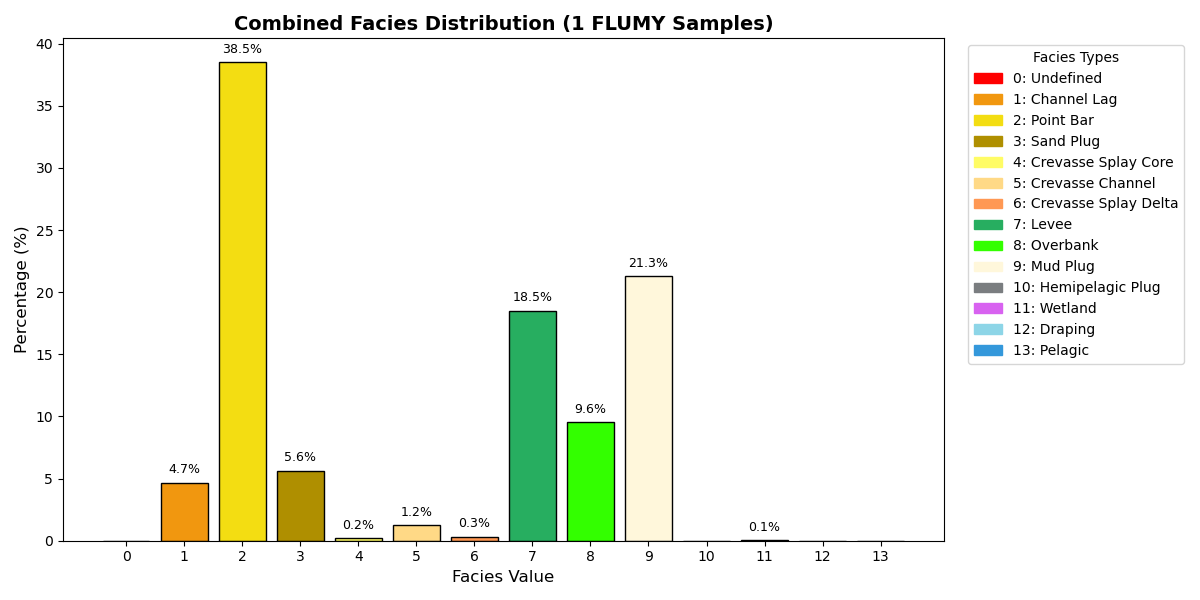

In [11]:
total_counts = np.zeros(14, dtype=np.int64)
print("Crunching the data...")

for i, f in enumerate(files):
    filepath = os.path.join(base, f)
    with np.load(filepath) as data:
        grid = data['facies']
        # Extract counts, forcing length to 14 (values 0-13)
        file_counts = np.bincount(grid.ravel(), minlength=14)
        total_counts += file_counts

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(files)} files...")

print("\nProcessing complete! Calculating distribution...")

# Calculate percentages
total_voxels = total_counts.sum()
percentages = (total_counts / total_voxels) * 100

# Print formatted text output with Facies Names
print("\n--- Overall Facies Distribution ---")
for val in range(14):
    if total_counts[val] > 0:
        facies_name = val_to_info[val]['name']
        print(f"[{val:2d}] {facies_name:<22}: {percentages[val]:6.2f}% ({total_counts[val]:,} voxels)")


# --- Visualization ---
plt.figure(figsize=(12, 6)) # Made slightly wider to fit the legend

x_values = np.arange(14)
# Map the colors from the dictionary to a list in order from 0 to 13
bar_colors = [val_to_info[val]['color'] for val in x_values]

# Create the bar chart
bars = plt.bar(x_values, percentages, color=bar_colors, edgecolor='black')

# Add data labels on top of the bars
for bar in bars:
    height = bar.get_height()
    if height > 0: 
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Build custom legend handles using the dictionary
legend_patches = [
    mpatches.Patch(color=val_to_info[val]['color'], label=f"{val}: {val_to_info[val]['name']}")
    for val in x_values
]


plt.legend(handles=legend_patches, title="Facies Types", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.title(f'Combined Facies Distribution ({len(files)} FLUMY Samples)', fontsize=14, weight='bold')
plt.xlabel('Facies Value', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(x_values) 
plt.tight_layout()
# plt.savefig('facies_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
38.6 + 26.9 + 4.8 + 5.7

76.0